In [1]:
import pandas as pd
import os
import numpy as np
import nltk
import zipfile
import os
from bs4 import BeautifulSoup
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Administration, economics and law.csv to Administration, economics and law.csv
Saving Body and beauty care.csv to Body and beauty care.csv
Saving Building and construction.csv to Building and construction.csv
Saving Crafts.csv to Crafts.csv
Saving Culture, media, design.csv to Culture, media, design.csv
Saving Data & IT.csv to Data & IT.csv
Saving Decontamination and sanitation.csv to Decontamination and sanitation.csv
Saving Health care.csv to Health care.csv
Saving Hotel, restaurant, catering.csv to Hotel, restaurant, catering.csv
Saving Industrial manufacturing.csv to Industrial manufacturing.csv
Saving Installation, operation and maintenance.csv to Installation, operation and maintenance.csv
Saving Managers and supervisors.csv to Managers and supervisors.csv
Saving Military occupations.csv to Military occupations.csv
Saving Natural agriculture.csv to Natural agriculture.csv
Saving Pedagogical occupations.csv to Pedagogical occupations.csv
Saving Sales, purchasing and marketi

In [3]:
# Load jobs CSV files by name, keeping only title_en column
jobs_files = [
    'Administration, economics and law.csv', 'Body and beauty care.csv',
    'Building and construction.csv', 'Crafts.csv', 'Culture, media, design.csv',
    'Data & IT.csv', 'Decontamination and sanitation.csv', 'Health care.csv',
    'Hotel, restaurant, catering.csv', 'Industrial manufacturing.csv',
    'Installation, operation and maintenance.csv', 'Managers and supervisors.csv',
    'Military occupations.csv', 'Natural agriculture.csv', 'Pedagogical occupations.csv',
    'Sales, purchasing and marketing.csv', 'Security and surveillance.csv',
    'Social occupations.csv', 'Technical occupations.csv',
    'Transport, distribution, storage.csv'
]

loaded_dfs = []
successfully_loaded = []
failed_to_load = []

for filename in jobs_files:
    if filename in uploaded:  # file was uploaded
        try:
            df = pd.read_csv(filename, usecols=["title_en"])  # <-- only load title_en
            loaded_dfs.append(df)
            successfully_loaded.append(filename)
        except Exception as e:
            print(f"Error loading {filename}: {e}")
            failed_to_load.append(filename)
    else:
        failed_to_load.append(filename)

# Concatenate all loaded dataframes
if loaded_dfs:
    jobs_df_final = pd.concat(loaded_dfs, ignore_index=True)
else:
    jobs_df_final = pd.DataFrame(columns=["title_en"])  # empty fallback

# Summary
print(f"Files uploaded this session: {list(uploaded.keys())}")
print(f"Files successfully loaded: {successfully_loaded}")
print(f"Files not uploaded or failed to load: {failed_to_load}")

print(f"\nTotal rows in combined jobs_df_final: {len(jobs_df_final)}")
print(jobs_df_final.head())

Files uploaded this session: ['Administration, economics and law.csv', 'Body and beauty care.csv', 'Building and construction.csv', 'Crafts.csv', 'Culture, media, design.csv', 'Data & IT.csv', 'Decontamination and sanitation.csv', 'Health care.csv', 'Hotel, restaurant, catering.csv', 'Industrial manufacturing.csv', 'Installation, operation and maintenance.csv', 'Managers and supervisors.csv', 'Military occupations.csv', 'Natural agriculture.csv', 'Pedagogical occupations.csv', 'Sales, purchasing and marketing.csv', 'Security and surveillance.csv', 'Social occupations.csv', 'Technical occupations.csv', 'Transport, distribution, storage.csv']
Files successfully loaded: ['Administration, economics and law.csv', 'Body and beauty care.csv', 'Building and construction.csv', 'Crafts.csv', 'Culture, media, design.csv', 'Data & IT.csv', 'Decontamination and sanitation.csv', 'Health care.csv', 'Hotel, restaurant, catering.csv', 'Industrial manufacturing.csv', 'Installation, operation and mainten

In [4]:
jobs_df_final

,title_en
0,Temporary HR Specialist - Employer Branding
1,Temporary HR Specialist- Employer Branding
2,Quality developer
3,PhD Research Fellowship in Social Work
4,Traffic Officer
...,...
1651,Warehouse worker for the Aids business in Kalix
1652,Temporary truck driver
1653,LTH is looking for summer staff - machine driv...
1654,LTH is looking for summer staff - drivers for ...


In [5]:
jobs_df_final = jobs_df_final.rename(columns={'title_en': 'job_summary'})

In [6]:
jobs_df_final

,job_summary
0,Temporary HR Specialist - Employer Branding
1,Temporary HR Specialist- Employer Branding
2,Quality developer
3,PhD Research Fellowship in Social Work
4,Traffic Officer
...,...
1651,Warehouse worker for the Aids business in Kalix
1652,Temporary truck driver
1653,LTH is looking for summer staff - machine driv...
1654,LTH is looking for summer staff - drivers for ...


In [7]:
from google.colab import files
uploaded = files.upload()

Saving 1_talents_1-500.csv to 1_talents_1-500.csv
Saving 2_talents_501-1000.csv to 2_talents_501-1000.csv
Saving 3_talents_1001-1500.csv to 3_talents_1001-1500.csv
Saving 4_talents_1501-2000.csv to 4_talents_1501-2000.csv
Saving 5_talents_2001-2500.csv to 5_talents_2001-2500.csv
Saving 6_talents_2501-3000.csv to 6_talents_2501-3000.csv
Saving 7_talents_3001-3500.csv to 7_talents_3001-3500.csv
Saving 8_talents_3501-4000.csv to 8_talents_3501-4000.csv
Saving 9_talents_4001-4500.csv to 9_talents_4001-4500.csv
Saving 10_talents_4501-5000.csv to 10_talents_4501-5000.csv
Saving 11_talents_5001-5500.csv to 11_talents_5001-5500.csv
Saving 12_talents_5501-6000.csv to 12_talents_5501-6000.csv
Saving 13_talents_6001-6500.csv to 13_talents_6001-6500.csv
Saving 14_talents_6501-7000.csv to 14_talents_6501-7000.csv


In [8]:
# List of resume files
resume_files = [
    '1_talents_1-500.csv', '2_talents_501-1000.csv', '3_talents_1001-1500.csv',
    '4_talents_1501-2000.csv', '5_talents_2001-2500.csv', '6_talents_2501-3000.csv',
    '7_talents_3001-3500.csv', '8_talents_3501-4000.csv', '9_talents_4001-4500.csv',
    '10_talents_4501-5000.csv', '11_talents_5001-5500.csv', '12_talents_5501-6000.csv',
    '13_talents_6001-6500.csv', '14_talents_6501-7000.csv'
]

# Columns we want to load
resume_columns = ["about", "tools", "skills", "educations", "experiences", "certifications"]

# Initialize lists
loaded_dfs = []
successfully_loaded = []
failed_to_load = []

# Load only selected columns
for filename in resume_files:
    if filename in uploaded:
        try:
            df = pd.read_csv(filename, usecols=resume_columns)
            loaded_dfs.append(df)
            successfully_loaded.append(filename)
        except Exception as e:
            print(f"Error loading {filename}: {e}")
            failed_to_load.append(filename)
    else:
        failed_to_load.append(filename)

# Concatenate loaded DataFrames if any
if loaded_dfs:
    resume_df_final = pd.concat(loaded_dfs, ignore_index=True)
else:
    resume_df_final = pd.DataFrame(columns=resume_columns)  # Empty fallback

# Print summary
print(f"Files uploaded this session: {list(uploaded.keys())}")
print(f"Files successfully loaded: {successfully_loaded}")
print(f"Files not uploaded or failed to load: {failed_to_load}")
print(f"\nTotal rows in combined resume_df: {len(resume_df_final)}")
print(resume_df_final.head())

Files uploaded this session: ['1_talents_1-500.csv', '2_talents_501-1000.csv', '3_talents_1001-1500.csv', '4_talents_1501-2000.csv', '5_talents_2001-2500.csv', '6_talents_2501-3000.csv', '7_talents_3001-3500.csv', '8_talents_3501-4000.csv', '9_talents_4001-4500.csv', '10_talents_4501-5000.csv', '11_talents_5001-5500.csv', '12_talents_5501-6000.csv', '13_talents_6001-6500.csv', '14_talents_6501-7000.csv']
Files successfully loaded: ['1_talents_1-500.csv', '2_talents_501-1000.csv', '3_talents_1001-1500.csv', '4_talents_1501-2000.csv', '5_talents_2001-2500.csv', '6_talents_2501-3000.csv', '7_talents_3001-3500.csv', '8_talents_3501-4000.csv', '9_talents_4001-4500.csv', '10_talents_4501-5000.csv', '11_talents_5001-5500.csv', '12_talents_5501-6000.csv', '13_talents_6001-6500.csv', '14_talents_6501-7000.csv']
Files not uploaded or failed to load: []

Total rows in combined resume_df: 6824
                                               about  \
0  I am a goal-oriented university engineer in el

In [9]:
resume_df_final

,about,tools,skills,educations,experiences,certifications
0,I am a goal-oriented university engineer in el...,"['LabVIEW', 'Python', 'Matlab', 'LTSpice', 'So...","['Electrical engineering', 'Teamwork', 'Adapta...",[{'course': 'Högskoleingenjör i elektroteknik'...,"[{'company': 'WSP', 'end_date': '2023-10-01', ...",[]
1,Master's degree in Tribology (TRIBOS+ Joint De...,[],"['MATLAB & Simulink', 'Solidworks Ansys (Mater...","[{'course': 'Tribology (TRIBOS+ Joint Degree, ...","[{'company': 'LTU Business', 'end_date': '2024...",[]
2,Currently studying at Universidad Francisco de...,"['Office Suite (Excel, Word, PowerPoint)', 'Ad...","['Pre-production departments', 'Production and...",[{'course': 'Audiovisual Communication and Adv...,"[{'company': 'Telecinco - Production', 'end_da...",NaN
3,Motivated and ambitious mechanical engineer wi...,"['Microsoft Office', 'SolidWorks', 'Gambit', '...","['Telecommunications', 'Project Management', '...","[{'course': 'Energy Conversion', 'degree': 'Ma...","[{'company': 'HIWEB holding', 'end_date': None...",NaN
4,"I am an enthusiastic kind of person, exception...",NaN,"['Working on Excel/MS Office', 'Comfortable at...",[{'course': 'MBA - INTERNATIONAL BUSINESS ADMI...,"[{'company': 'Jensens Bofhus', 'end_date': Non...",NaN
...,...,...,...,...,...,...
6819,Senior Engineering Management Professional wit...,"['PLSCADD', 'PLSPOLE', 'PLSTOWER', 'STAAD Pro']","['Project Management', 'Electrical Engineering...","[{'course': 'Strategic Leadership', 'degree': ...","[{'company': 'Sterlite Power, Gurugram', 'end_...",NaN
6820,"Excellence through hard working, loyalty, sens...",[],[],[{'course': 'Junior High School Certificate B....,"[{'company': 'SEAWORKS COMPANY (QATAR)', 'end_...",[]
6821,"Event Coordinator, experienced in Tourism. Com...",NaN,"['Teamwork', 'Problem-solving', 'Customer serv...","[{'course': 'Public Accountant', 'degree': 'nu...",[{'company': 'United Nations International Eme...,NaN
6822,Project Engineer with experience in mechanical...,"['ANSYS', 'Python', 'SQL', 'Arduino', 'LaTeX']","['Mechanical Engineering', 'Manufacturing Proc...",[{'course': 'MSc in Space Science and Technolo...,"[{'company': 'ACTAS Space', 'end_date': '2023-...",[]


In [10]:
# create the summary (your code)
resume_df_final['resume_summary'] = (
    resume_df_final[resume_columns]
    .fillna('')
    .agg(lambda x: ' '.join(x).strip(), axis=1)
)

# drop the original columns
resume_df_final.drop(columns=resume_columns, inplace=True)

In [11]:
resume_df_final

,resume_summary
0,I am a goal-oriented university engineer in el...
1,Master's degree in Tribology (TRIBOS+ Joint De...
2,Currently studying at Universidad Francisco de...
3,Motivated and ambitious mechanical engineer wi...
4,"I am an enthusiastic kind of person, exception..."
...,...
6819,Senior Engineering Management Professional wit...
6820,"Excellence through hard working, loyalty, sens..."
6821,"Event Coordinator, experienced in Tourism. Com..."
6822,Project Engineer with experience in mechanical...


In [12]:
!pip install --upgrade scipy

In [13]:
# Download necessary NLTK resources (only need to run once)
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [14]:
def preprocess_text(text):
    """
    Preprocesses a given text string for NLP tasks. This includes cleaning the text,
    tokenizing, removing stopwords, and lemmatizing the words.

    Args:
    text (str): The text string to preprocess.

    Returns:
    str: The preprocessed text.
    """
    if not isinstance(text, str):  # Safeguard against non-string input like NaN
        return ""

     # 1. Add spaces around tags, then remove them
    text = re.sub(r'<[^>]+>', ' ', text)

    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Remove emails
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)

    # 4. Remove special characters (keep only words and whitespace)
    text = re.sub(r'[^\w\s]', '', text)

    #5 Trip out all non-ASCII characters like â, €, ™, etc., that appear due to encoding mismatches
    text = text.encode('ascii', 'ignore').decode()

    text = text.lower()

    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]

    lemmatizer = WordNetLemmatizer()
    lemmatized_text = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    return ' '.join(lemmatized_text)

In [16]:
# Apply preprocessing
# Keep original resume text in a new column
resume_df_final['Resume_original'] = resume_df_final['resume_summary']

# Apply preprocessing only on 'Resume'
resume_df_final['resume_summary'] = resume_df_final['resume_summary'].apply(preprocess_text)

In [17]:
resume_df_final

,resume_summary,Resume_original
0,goaloriented university engineer electrical en...,I am a goal-oriented university engineer in el...
1,master degree tribology tribos joint degree er...,Master's degree in Tribology (TRIBOS+ Joint De...
2,currently studying universidad francisco de vi...,Currently studying at Universidad Francisco de...
3,motivated ambitious mechanical engineer 7 year...,Motivated and ambitious mechanical engineer wi...
4,enthusiastic kind person exceptional communica...,"I am an enthusiastic kind of person, exception..."
...,...,...
6819,senior engineering management professional 21 ...,Senior Engineering Management Professional wit...
6820,excellence hard working loyalty sense integrit...,"Excellence through hard working, loyalty, sens..."
6821,event coordinator experienced tourism committe...,"Event Coordinator, experienced in Tourism. Com..."
6822,project engineer experience mechanical calcula...,Project Engineer with experience in mechanical...


In [18]:
jobs_df_final

,job_summary
0,Temporary HR Specialist - Employer Branding
1,Temporary HR Specialist- Employer Branding
2,Quality developer
3,PhD Research Fellowship in Social Work
4,Traffic Officer
...,...
1651,Warehouse worker for the Aids business in Kalix
1652,Temporary truck driver
1653,LTH is looking for summer staff - machine driv...
1654,LTH is looking for summer staff - drivers for ...


In [19]:
def drop_duplicates(df, column_name):
    """
    Drops duplicates based on a specified column from the DataFrame.

    Args:
    df (pd.DataFrame): The DataFrame from which to remove duplicates.
    column_name (str): The name of the column based on which duplicates will be identified.

    Returns:
    pd.DataFrame: DataFrame with duplicates removed based on the specified column.
    """
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")

    original_size = df.shape[0]
    df_cleaned = df.drop_duplicates(subset=[column_name])
    new_size = df_cleaned.shape[0]

    print(f"Dropped {original_size - new_size} duplicates from '{column_name}'. New dataset size: {new_size}")

    return df_cleaned

In [20]:
jobs_df_final = drop_duplicates(jobs_df_final, column_name='job_summary')

Dropped 316 duplicates from 'job_summary'. New dataset size: 1340


In [21]:
resume_df_final = drop_duplicates(resume_df_final, column_name='Resume_original')

Dropped 19 duplicates from 'Resume_original'. New dataset size: 6805


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ----------------------------
# Split function (same as before)
# ----------------------------
def split_df(df, train_frac=0.8, val_frac=0.1, random_state=42):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    n = len(df_shuffled)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    train_df = df_shuffled.iloc[:train_end].reset_index(drop=True)
    val_df = df_shuffled.iloc[train_end:val_end].reset_index(drop=True)
    test_df = df_shuffled.iloc[val_end:].reset_index(drop=True)
    return train_df, val_df, test_df


In [46]:
# Perform one evaluation run
# ----------------------------
def perform_tfidf_evaluation(resume_df, jobs_df, random_seed=42, initial_threshold=0.7):
    # Split data
    resume_train, resume_val, resume_test = split_df(resume_df, random_state=random_seed)
    jobs_train, jobs_val, jobs_test = split_df(jobs_df, random_state=random_seed)

    # Fit TF-IDF on combined training texts
    combined_train_texts = pd.concat([jobs_train['job_summary'], resume_train['resume_summary']])
    tfidf = TfidfVectorizer(
        stop_words='english',
        max_features=10000,
        ngram_range=(1,1),
        min_df=2,
        norm='l2'
    )
    tfidf.fit(combined_train_texts)

    # Transform test sets
    jobs_test_vectors = tfidf.transform(jobs_test['job_summary'])
    resumes_test_vectors = tfidf.transform(resume_test['resume_summary'])

    # Compute similarity (resumes × jobs)
    similarity_matrix = cosine_similarity(resumes_test_vectors, jobs_test_vectors)

    # Collect all matches
    results = []
    for resume_idx in range(similarity_matrix.shape[0]):
        for job_idx in range(similarity_matrix.shape[1]):
            score = similarity_matrix[resume_idx, job_idx]
            results.append({
                'resume_index': resume_idx,
                'job_index': job_idx,
                'similarity_score': score,
                'resume_summary': resume_test.iloc[resume_idx]['resume_summary'],
                'resume_original': resume_test.iloc[resume_idx]['Resume_original'],
                'job_summary': jobs_test.iloc[job_idx]['job_summary'],
                'is_correct': score >= initial_threshold
            })

    matches_df = pd.DataFrame(results)

    # Hard-coded threshold (no adjustment)
    similarity_threshold = initial_threshold

    # Metrics
    metrics = {
        'avg_similarity': matches_df['similarity_score'].mean(),
        'median_similarity': matches_df['similarity_score'].median(),
        'std_similarity': matches_df['similarity_score'].std(),
        'accuracy': matches_df['is_correct'].mean(),
        'num_matches': len(matches_df),
        'num_correct_matches': matches_df['is_correct'].sum(),
        'pct_correct_matches': matches_df['is_correct'].mean() * 100,
        'threshold_used': similarity_threshold
    }

    return metrics, matches_df


In [47]:
# Run multiple evaluations
# ----------------------------
def run_multiple_tfidf_evaluations(resume_df, jobs_df, num_runs=5, initial_threshold=0.7):
    all_metrics = []
    all_matches_dfs = []

    for run in tqdm(range(num_runs), desc="Running TF-IDF Evaluations"):
        random_seed = 42 + run
        metrics, matches_df = perform_tfidf_evaluation(resume_df, jobs_df, random_seed, initial_threshold)

        metrics['run'] = run + 1
        matches_df['run'] = run + 1

        all_metrics.append(metrics)
        all_matches_dfs.append(matches_df)

    metrics_df = pd.DataFrame(all_metrics)
    combined_df = pd.concat(all_matches_dfs)

    # Print summary
    print("\n=== TF-IDF EVALUATION SUMMARY ===")
    print(f"Average similarity: {metrics_df['avg_similarity'].mean():.3f} ± {metrics_df['avg_similarity'].std():.3f}")
    print(f"Median similarity: {metrics_df['median_similarity'].mean():.3f}")
    print(f"Std deviation: {metrics_df['std_similarity'].mean():.3f}")
    print(f"Average accuracy: {metrics_df['accuracy'].mean():.3f} ± {metrics_df['accuracy'].std():.3f}")
    print(f"Average correct matches: {metrics_df['num_correct_matches'].mean():.1f}")
    print(f"Average % correct matches: {metrics_df['pct_correct_matches'].mean():.2f}%")
    print(f"Threshold used: {initial_threshold}")

    return metrics_df, combined_df



In [48]:
# Run it
# ----------------------------
num_runs = 5
initial_threshold = 0.7

metrics_df_tfidf, combined_df_tfidf = run_multiple_tfidf_evaluations(
    resume_df_final,
    jobs_df_final,
    num_runs=num_runs,
    initial_threshold=initial_threshold
)

# Save results
combined_df_tfidf.to_csv("tfidf_all_similarity_scores.csv", index=False)
metrics_df_tfidf.to_csv("tfidf_evaluation_metrics.csv", index=False)

Running TF-IDF Evaluations:   0%|          | 0/5 [00:00<?, ?it/s]


=== TF-IDF EVALUATION SUMMARY ===
Average similarity: 0.008 ± 0.001
Median similarity: 0.000
Std deviation: 0.023
Average accuracy: 0.000 ± 0.000
Average correct matches: 0.0
Average % correct matches: 0.00%
Threshold used: 0.7


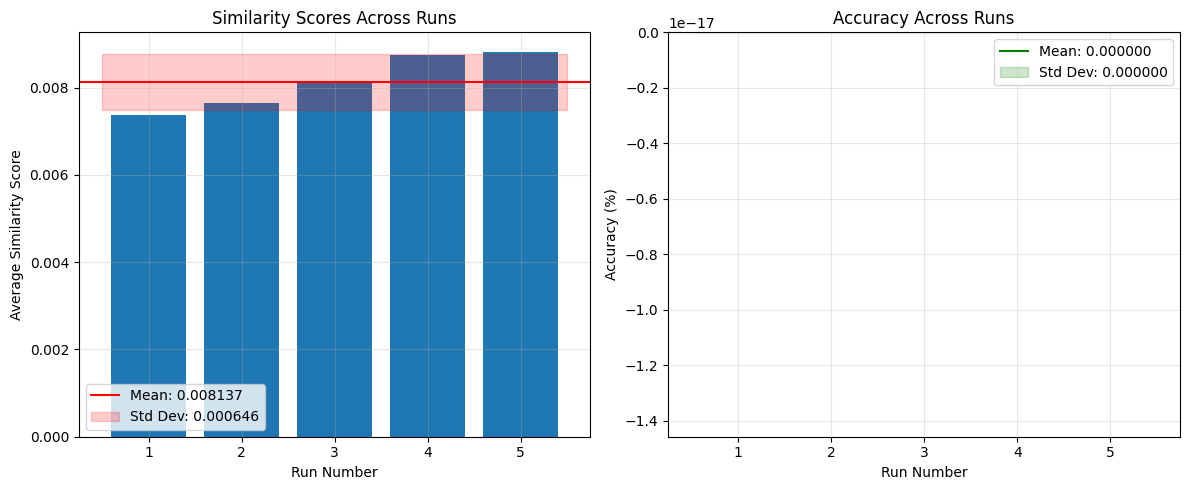

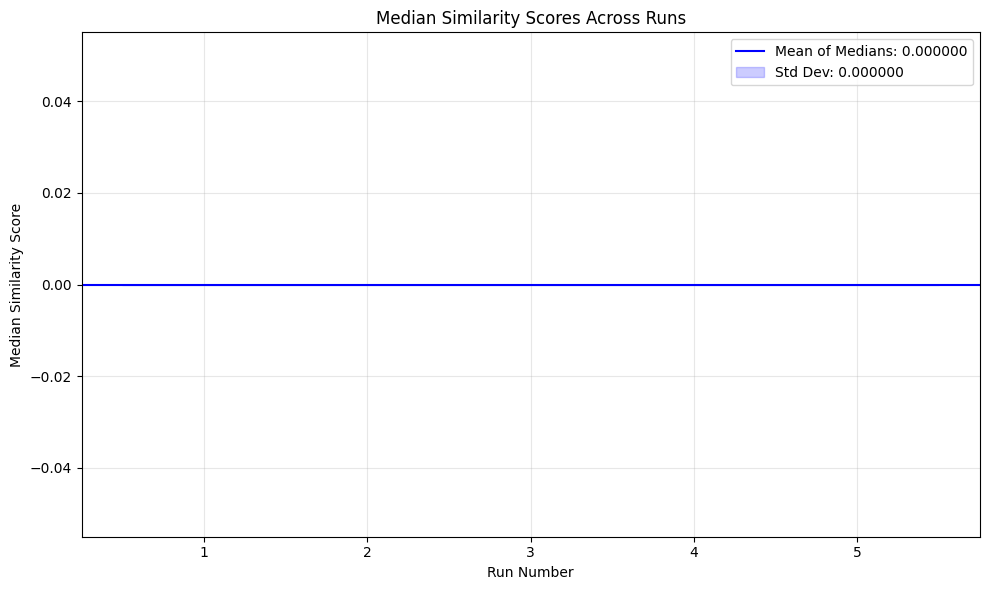

In [49]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Average similarity plot
axes[0].bar(metrics_df_tfidf['run'], metrics_df_tfidf['avg_similarity'])
axes[0].axhline(y=metrics_df_tfidf['avg_similarity'].mean(), color='r', linestyle='-',
                label=f'Mean: {metrics_df_tfidf["avg_similarity"].mean():.6f}')
axes[0].fill_between(
    [0.5, len(metrics_df_tfidf)+0.5],
    [metrics_df_tfidf['avg_similarity'].mean() - metrics_df_tfidf['avg_similarity'].std()]*2,
    [metrics_df_tfidf['avg_similarity'].mean() + metrics_df_tfidf['avg_similarity'].std()]*2,
    color='r', alpha=0.2, label=f'Std Dev: {metrics_df_tfidf["avg_similarity"].std():.6f}'
)
axes[0].set_xlabel('Run Number')
axes[0].set_ylabel('Average Similarity Score')
axes[0].set_title('Similarity Scores Across Runs')
axes[0].set_xticks(metrics_df_tfidf['run'])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].bar(metrics_df_tfidf['run'], metrics_df_tfidf['pct_correct_matches'])
axes[1].axhline(y=metrics_df_tfidf['pct_correct_matches'].mean(), color='g', linestyle='-',
                label=f'Mean: {metrics_df_tfidf["pct_correct_matches"].mean():.6f}')
axes[1].fill_between(
    [0.5, len(metrics_df_tfidf)+0.5],
    [metrics_df_tfidf['pct_correct_matches'].mean() - metrics_df_tfidf['pct_correct_matches'].std()]*2,
    [metrics_df_tfidf['pct_correct_matches'].mean() + metrics_df_tfidf['pct_correct_matches'].std()]*2,
    color='g', alpha=0.2, label=f'Std Dev: {metrics_df_tfidf["pct_correct_matches"].std():.6f}'
)
axes[1].set_xlabel('Run Number')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Across Runs')
axes[1].set_xticks(metrics_df_tfidf['run'])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Median similarity scores in a separate figure
plt.figure(figsize=(10, 6))
plt.bar(metrics_df_tfidf['run'], metrics_df_tfidf['median_similarity'])
plt.axhline(y=metrics_df_tfidf['median_similarity'].mean(), color='b', linestyle='-',
            label=f'Mean of Medians: {metrics_df_tfidf["median_similarity"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df_tfidf)+0.5],
    [metrics_df_tfidf['median_similarity'].mean() - metrics_df_tfidf['median_similarity'].std()]*2,
    [metrics_df_tfidf['median_similarity'].mean() + metrics_df_tfidf['median_similarity'].std()]*2,
    color='b', alpha=0.2, label=f'Std Dev: {metrics_df_tfidf["median_similarity"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Median Similarity Score')
plt.title('Median Similarity Scores Across Runs')
plt.xticks(metrics_df_tfidf['run'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

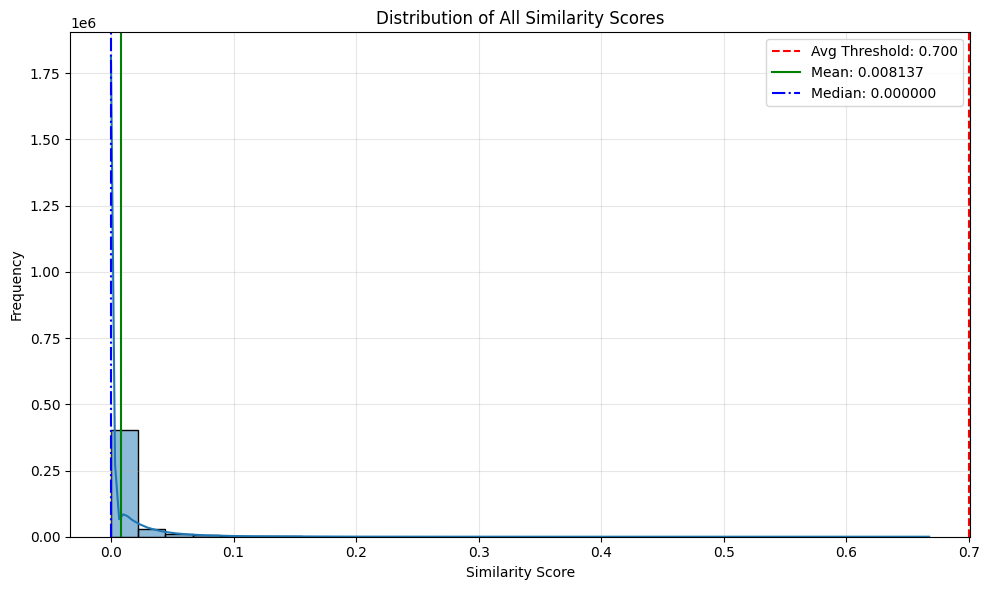

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(combined_df_tfidf['similarity_score'], bins=30, kde=True)

# Use the average threshold across runs
avg_threshold = metrics_df_tfidf['threshold_used'].mean()

plt.axvline(x=avg_threshold, color='r', linestyle='--', label=f'Avg Threshold: {avg_threshold:.3f}')
plt.axvline(x=metrics_df_tfidf['avg_similarity'].mean(), color='g', linestyle='-',
            label=f'Mean: {metrics_df_tfidf["avg_similarity"].mean():.6f}')
plt.axvline(x=metrics_df_tfidf['median_similarity'].mean(), color='b', linestyle='-.',
            label=f'Median: {metrics_df_tfidf["median_similarity"].mean():.6f}')

plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of All Similarity Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1101821073.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=metrics_df_tfidf['run'])


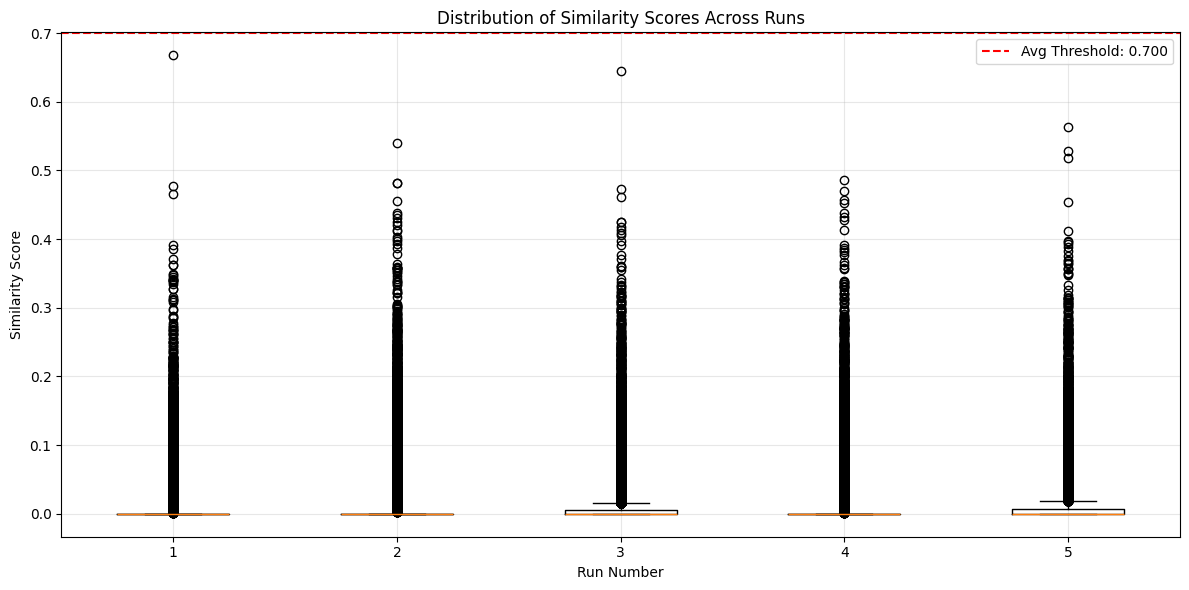

In [53]:
# 3. Box plot of similarity scores across runs
plt.figure(figsize=(12, 6))

# Create data for each run
boxplot_data = [
    combined_df_tfidf[combined_df_tfidf['run'] == run]['similarity_score']
    for run in metrics_df_tfidf['run']
]

# Draw boxplot
plt.boxplot(boxplot_data, labels=metrics_df_tfidf['run'])

# Use average threshold across runs
avg_threshold = metrics_df_tfidf['threshold_used'].mean()
plt.axhline(y=avg_threshold, color='r', linestyle='--', label=f'Avg Threshold: {avg_threshold:.3f}')

plt.xlabel('Run Number')
plt.ylabel('Similarity Score')
plt.title('Distribution of Similarity Scores Across Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

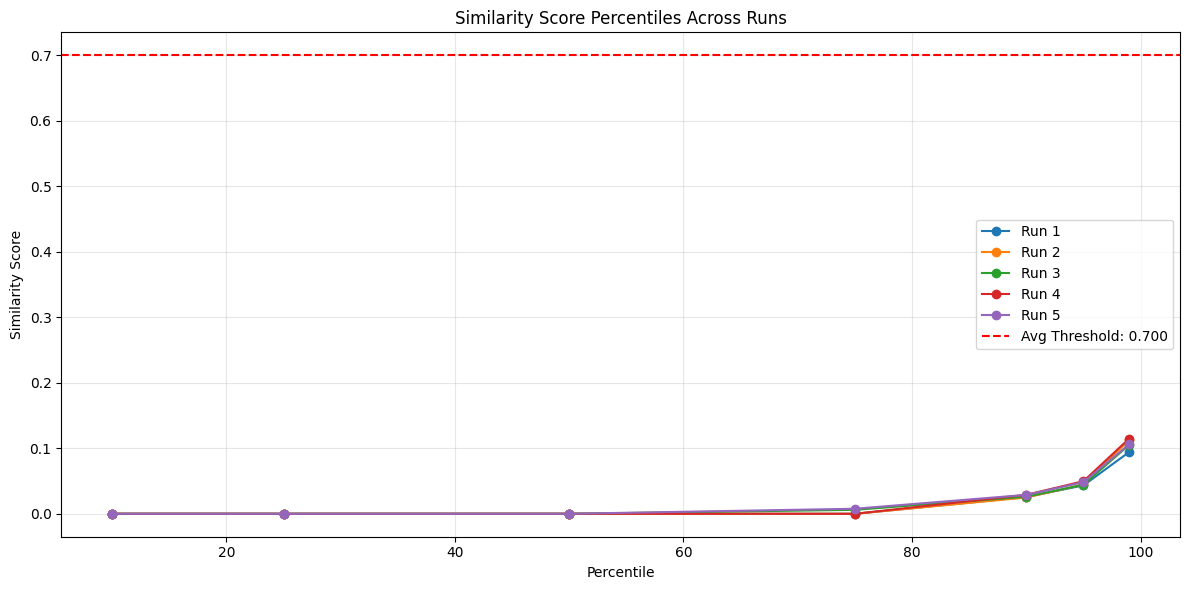

In [54]:
# 4. Percentile analysis
percentiles = [10, 25, 50, 75, 90, 95, 99]
plt.figure(figsize=(12, 6))

for run in metrics_df_tfidf['run']:
    run_data = combined_df_tfidf[combined_df_tfidf['run'] == run]['similarity_score']
    percentile_values = np.percentile(run_data, percentiles)
    plt.plot(percentiles, percentile_values, marker='o', label=f'Run {run}')

# Use average threshold across runs
avg_threshold = metrics_df_tfidf['threshold_used'].mean()
plt.axhline(y=avg_threshold, color='r', linestyle='--', label=f'Avg Threshold: {avg_threshold:.3f}')

plt.xlabel('Percentile')
plt.ylabel('Similarity Score')
plt.title('Similarity Score Percentiles Across Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

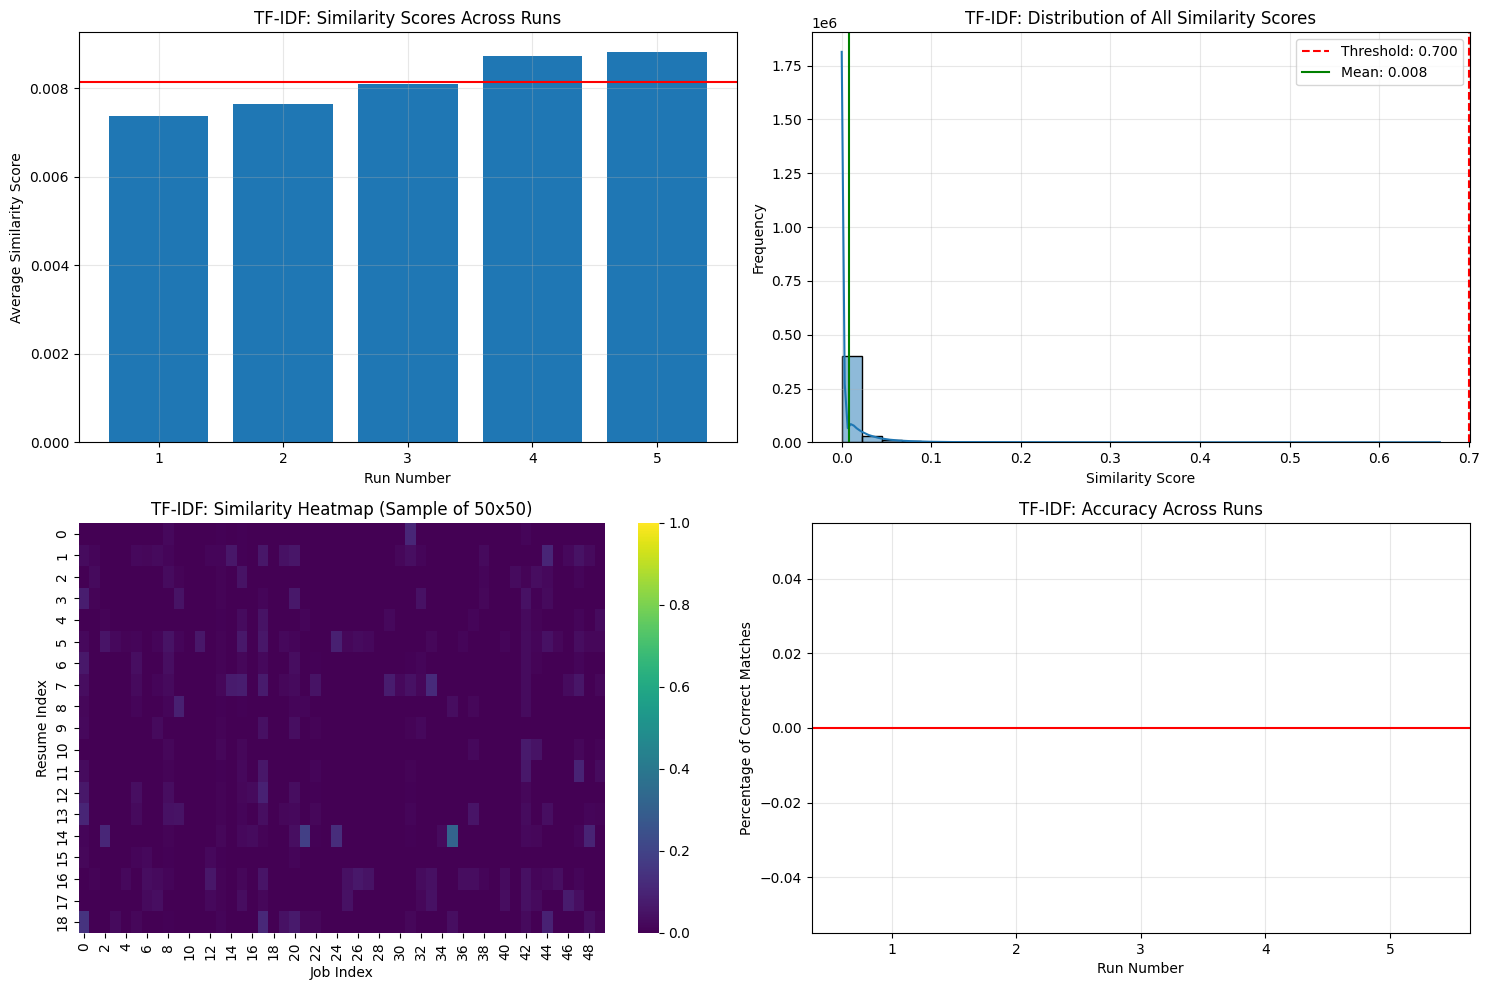


=== EXAMPLES OF HIGH SIMILARITY MATCHES ===

Similarity Score: 0.668
Resume (processed): special education teacher experience assessing childrens ability collaborating ieps using rehabilita...
Resume (before preprocessing): Special Education Teacher with experience in assessing children's abilities, collaborating with IEPs...
Matched Job Summary: Special education teacher year 7-9...
--------------------------------------------------

Similarity Score: 0.645
Resume (processed): shipbuilding electrician industrial electrician sailor construction electrician course electrician d...
Resume (before preprocessing): ['Shipbuilding electrician', 'Industrial electrician', 'Sailor', 'Construction electrician'] [{'cour...
Matched Job Summary: Electrician...
--------------------------------------------------

Similarity Score: 0.563
Resume (processed): compassionate special education teacher 8 year experience working intellectual developmental disorde...
Resume (before preprocessing): Compassion

In [56]:
# =====================================
# TF-IDF VISUALIZATIONS (adapted version)
# =====================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(15, 10))

# Plot 1: Average similarity across runs
plt.subplot(2, 2, 1)
plt.bar(metrics_df_tfidf['run'], metrics_df_tfidf['avg_similarity'])
plt.axhline(y=metrics_df_tfidf['avg_similarity'].mean(), color='r', linestyle='-')
plt.xlabel('Run Number')
plt.ylabel('Average Similarity Score')
plt.title('TF-IDF: Similarity Scores Across Runs')
plt.grid(True, alpha=0.3)

# Plot 2: Distribution of similarity scores
plt.subplot(2, 2, 2)
sns.histplot(combined_df_tfidf['similarity_score'], bins=30, kde=True)
similarity_threshold = metrics_df_tfidf['threshold_used'].mean()  # average threshold used
plt.axvline(x=similarity_threshold, color='r', linestyle='--', label=f'Threshold: {similarity_threshold:.3f}')
plt.axvline(x=metrics_df_tfidf['avg_similarity'].mean(), color='g', linestyle='-',
            label=f'Mean: {metrics_df_tfidf["avg_similarity"].mean():.3f}')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('TF-IDF: Distribution of All Similarity Scores')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Heatmap of similarity scores (sample from run 1)
plt.subplot(2, 2, 3)
sample_size = min(50, combined_df_tfidf[combined_df_tfidf['run'] == 1]['resume_index'].nunique())
pivot_df = combined_df_tfidf[combined_df_tfidf['run'] == 1].iloc[:sample_size*sample_size]
pivot_matrix = pivot_df.pivot_table(
    index='resume_index',
    columns='job_index',
    values='similarity_score',
    aggfunc='mean'
).iloc[:sample_size, :sample_size]

sns.heatmap(pivot_matrix, cmap='viridis', vmin=0, vmax=1)
plt.title(f'TF-IDF: Similarity Heatmap (Sample of {sample_size}x{sample_size})')
plt.xlabel('Job Index')
plt.ylabel('Resume Index')

# Plot 4: Accuracy across runs
plt.subplot(2, 2, 4)
plt.bar(metrics_df_tfidf['run'], metrics_df_tfidf['pct_correct_matches'])
plt.axhline(y=metrics_df_tfidf['pct_correct_matches'].mean(), color='r', linestyle='-')
plt.xlabel('Run Number')
plt.ylabel('Percentage of Correct Matches')
plt.title('TF-IDF: Accuracy Across Runs')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ================================
# Show examples of matches
# ================================
print("\n=== EXAMPLES OF HIGH SIMILARITY MATCHES ===")
high_sim = combined_df_tfidf.sort_values('similarity_score', ascending=False).head(3)
for _, row in high_sim.iterrows():
    print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
    print(f"Resume (processed): {row['resume_summary'][:100]}...")
    print(f"Resume (before preprocessing): {row['resume_original'][:100]}...")
    print(f"Matched Job Summary: {row['job_summary'][:100]}...")
    print("-" * 50)

print("\n=== EXAMPLES OF LOW SIMILARITY MATCHES ===")
low_sim = combined_df_tfidf.sort_values('similarity_score').head(3)
for _, row in low_sim.iterrows():
    print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
    print(f"Resume (processed): {row['resume_summary'][:100]}...")
    print(f"Resume (before preprocessing): {row['resume_original'][:100]}...")
    print(f"Matched Job Summary: {row['job_summary'][:100]}...")
    print("-" * 50)


# ================================
# Percentile analysis
# ================================
percentiles = [10, 25, 50, 75, 90, 95, 99]
score_percentiles = np.percentile(combined_df_tfidf['similarity_score'], percentiles)

print("\n=== TF-IDF SIMILARITY SCORE PERCENTILES ===")
for p, score in zip(percentiles, score_percentiles):
    print(f"{p}th percentile: {score:.3f}")


# ================================
# Save results
# ================================
combined_df_tfidf.to_csv('tfidf_all_similarity_scores.csv', index=False)
metrics_df_tfidf.to_csv('tfidf_evaluation_metrics.csv', index=False)

print("\n=== TF-IDF EVALUATION COMPLETE ===")
print(f"Total matches evaluated: {len(combined_df_tfidf)}")
print("Results saved to CSV files")


=== TF-IDF SIMILARITY SCORES OF WRONG PREDICTIONS ===
count    456270.000000
mean          0.008137
std           0.022832
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.667636
Name: similarity_score, dtype: float64
Lowest wrong score: 0.000
Highest wrong score: 0.668


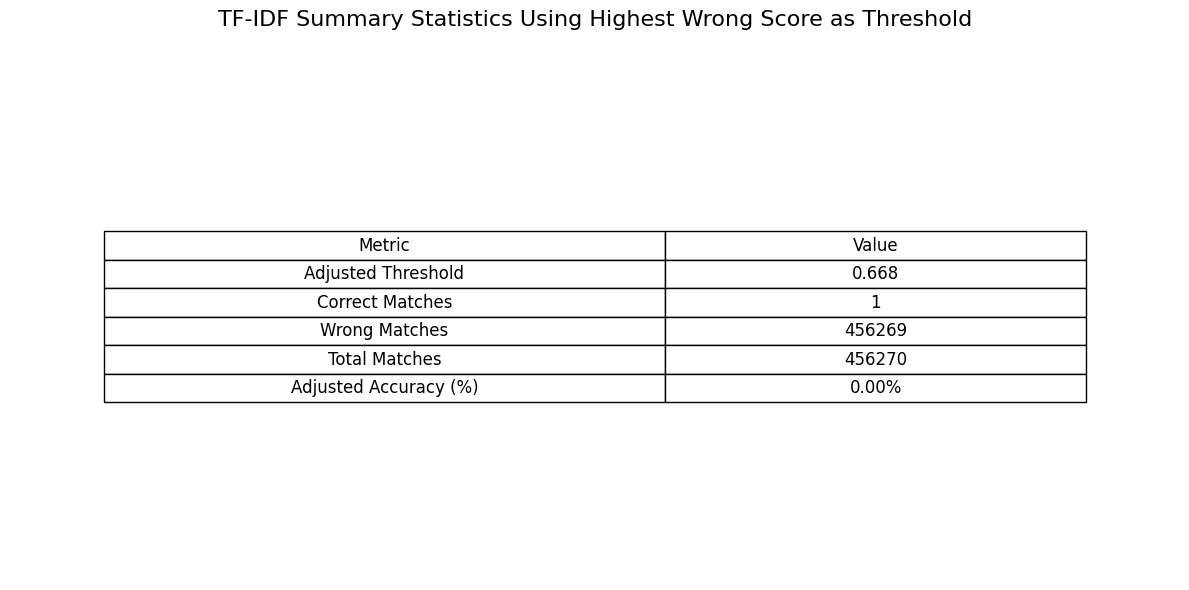

In [57]:
# =====================================
# Extract wrong predictions for TF-IDF
# =====================================
wrong_preds_tfidf = combined_df_tfidf[combined_df_tfidf['is_correct'] == False]

# Check the distribution of their similarity scores
print("\n=== TF-IDF SIMILARITY SCORES OF WRONG PREDICTIONS ===")
print(wrong_preds_tfidf['similarity_score'].describe())

# Lowest and highest scores among wrong predictions
lowest_wrong_score = wrong_preds_tfidf['similarity_score'].min()
highest_wrong_score = wrong_preds_tfidf['similarity_score'].max()

print(f"Lowest wrong score: {lowest_wrong_score:.3f}")
print(f"Highest wrong score: {highest_wrong_score:.3f}")

# Optional: set adjusted threshold to highest wrong score
adjusted_threshold_tfidf = highest_wrong_score
combined_df_tfidf['is_correct_adjusted'] = combined_df_tfidf['similarity_score'] >= adjusted_threshold_tfidf

# Count correct and wrong matches based on adjusted threshold
num_correct_tfidf = combined_df_tfidf['is_correct_adjusted'].sum()
num_wrong_tfidf = len(combined_df_tfidf) - num_correct_tfidf
accuracy_adjusted_tfidf = num_correct_tfidf / len(combined_df_tfidf) * 100

# Display summary table
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.axis('off')
table_data = [
    ['Metric', 'Value'],
    ['Adjusted Threshold', f"{adjusted_threshold_tfidf:.3f}"],
    ['Correct Matches', f"{num_correct_tfidf}"],
    ['Wrong Matches', f"{num_wrong_tfidf}"],
    ['Total Matches', f"{len(combined_df_tfidf)}"],
    ['Adjusted Accuracy (%)', f"{accuracy_adjusted_tfidf:.2f}%"]
]

table = plt.table(cellText=table_data, cellLoc='center', loc='center', colWidths=[0.4, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
plt.title('TF-IDF Summary Statistics Using Highest Wrong Score as Threshold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
